# Ch06 - DQN 完整实现

DeepMind 2015 里程碑算法：经验回放 + 目标网络。在 CartPole-v1 上训练。

> 本 Notebook 配套《强化学习全面教程》PDF 使用。

In [1]:
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import random
from collections import deque, defaultdict

# 中文字体配置
import os, platform
if platform.system() == 'Linux' and os.path.exists('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf'):
    fm.fontManager.addfont('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['Noto Sans SC', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__} | 设备: {device} | Gymnasium: {gym.__version__}')


PyTorch: 2.13.0+cpu | 设备: cpu | Gymnasium: 1.3.0


## 6.1 DQN 三大创新

1. **经验回放（Experience Replay）**：将 (s,a,r,s',done) 存入缓冲区，训练时随机采样
   - 打破数据时间相关性
   - 提高数据利用率
   - 稳定训练

2. **目标网络（Target Network）**：维护独立的目标网络，定期同步
   - 避免'目标值跟着 θ 立刻变化'的不稳定

3. **ε-greedy 探索**：ε 从 1.0 衰减到 0.05

## 6.2 网络结构与超参数

In [2]:
from collections import deque, namedtuple
import torch.optim as optim

Transition = namedtuple('Transition', ['state', 'action', 'reward', 'next_state', 'done'])

class ReplayBuffer:
    def __init__(self, capacity=10_000):
        self.buffer = deque(maxlen=capacity)
    def push(self, *args):
        self.buffer.append(Transition(*args))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))
    def __len__(self): return len(self.buffer)


class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, action_dim),
        )
    def forward(self, x): return self.net(x)


env = gym.make('CartPole-v1')
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
print(f'状态维度: {state_dim}, 动作数: {action_dim}')

状态维度: 4, 动作数: 2


## 6.3 DQN Agent 实现

In [3]:
class DQNAgent:
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99,
                 buffer_size=10_000, batch_size=64, target_sync=10,
                 epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=500):
        self.device = device
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_sync = target_sync

        self.policy_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_size)

        self.epsilon_start = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.steps = 0

    @property
    def epsilon(self):
        return self.epsilon_end + (self.epsilon_start - self.epsilon_end) * \
               np.exp(-self.steps / self.epsilon_decay)

    def act(self, state, eval_mode=False):
        if not eval_mode and random.random() < self.epsilon:
            return random.randrange(self.action_dim)
        with torch.no_grad():
            s = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            return int(self.policy_net(s).argmax(dim=1).item())

    def learn(self):
        if len(self.buffer) < self.batch_size:
            return None
        batch = self.buffer.sample(self.batch_size)
        s = torch.as_tensor(np.array(batch.state), dtype=torch.float32, device=device)
        a = torch.as_tensor(batch.action, dtype=torch.long, device=device).unsqueeze(1)
        r = torch.as_tensor(batch.reward, dtype=torch.float32, device=device)
        s_next = torch.as_tensor(np.array(batch.next_state), dtype=torch.float32, device=device)
        done = torch.as_tensor(batch.done, dtype=torch.float32, device=device)

        q_sa = self.policy_net(s).gather(1, a).squeeze(1)
        with torch.no_grad():
            q_next = self.target_net(s_next).max(dim=1)[0]
            q_target = r + self.gamma * q_next * (1 - done)

        loss = nn.functional.mse_loss(q_sa, q_target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), 10.0)
        self.optimizer.step()
        return loss.item()

    def sync_target(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

agent = DQNAgent(state_dim, action_dim)
print('DQN Agent 创建完成 ✓')

DQN Agent 创建完成 ✓


## 6.4 训练循环

运行约 200-400 回合可使 CartPole 达到 500 分。

In [4]:
import random
random.seed(42); np.random.seed(42); torch.manual_seed(42)

episodes = 200  # 可调高到 400 以获得更稳定结果
max_steps = 500
rewards = []

for ep in range(episodes):
    s, _ = env.reset(seed=42 + ep)
    total_r = 0
    for t in range(max_steps):
        a = agent.act(s)
        s_next, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated
        r_shaped = -10.0 if terminated and t < max_steps - 1 else r
        agent.buffer.push(s, a, r_shaped, s_next, done)
        s = s_next
        total_r += r
        agent.steps += 1
        agent.learn()
        if done: break
    if (ep + 1) % agent.target_sync == 0:
        agent.sync_target()
    rewards.append(total_r)
    if (ep + 1) % 20 == 0:
        avg = np.mean(rewards[-20:])
        print(f'ep {ep+1:3d} | reward={total_r:5.1f} | avg20={avg:5.1f} '
              f'| ε={agent.epsilon:.3f} | buf={len(agent.buffer)}')

ep  20 | reward= 39.0 | avg20= 20.6 | ε=0.468 | buf=411
ep  40 | reward=283.0 | avg20=129.0 | ε=0.052 | buf=2991
ep  60 | reward=335.0 | avg20=257.1 | ε=0.050 | buf=8134
ep  80 | reward=166.0 | avg20=196.5 | ε=0.050 | buf=10000
ep 100 | reward=109.0 | avg20=122.2 | ε=0.050 | buf=10000
ep 120 | reward=113.0 | avg20=118.8 | ε=0.050 | buf=10000
ep 140 | reward= 77.0 | avg20= 96.7 | ε=0.050 | buf=10000
ep 160 | reward=119.0 | avg20=112.2 | ε=0.050 | buf=10000
ep 180 | reward=123.0 | avg20=120.5 | ε=0.050 | buf=10000
ep 200 | reward=116.0 | avg20=115.1 | ε=0.050 | buf=10000


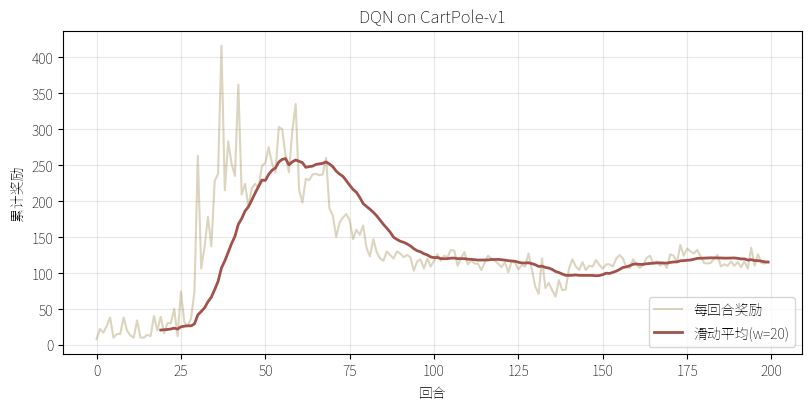

In [5]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.plot(rewards, alpha=0.3, color='#887129', label='每回合奖励')
if len(rewards) >= 20:
    ma = np.convolve(rewards, np.ones(20)/20, mode='valid')
    ax.plot(range(19, len(rewards)), ma, color='#a2524b', linewidth=2, label='滑动平均(w=20)')
ax.set_xlabel('回合'); ax.set_ylabel('累计奖励')
ax.set_title('DQN on CartPole-v1'); ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.show()

## 6.5 评估训练后的策略

In [6]:
eval_r = []
for ep in range(10):
    s, _ = env.reset(seed=1000 + ep)
    r_sum, done = 0, False
    while not done:
        a = agent.act(s, eval_mode=True)
        s, r, terminated, truncated, _ = env.step(a)
        r_sum += r
        done = terminated or truncated
    eval_r.append(r_sum)
print(f'评估平均奖励 (10回合): {np.mean(eval_r):.1f} ± {np.std(eval_r):.1f}')

评估平均奖励 (10回合): 108.1 ± 4.0


## 6.6 可视化训练效果

用训练好的策略跑一回合 CartPole，动画展示小车平衡杆的控制效果。

In [7]:
from viz_utils import visualize_cartpole
visualize_cartpole(lambda s: agent.act(s, eval_mode=True), title='DQN 策略可视化')

## 6.7 小结

**DQN 局限**：
- Q 值过估（解决：Double DQN，第 11 章）
- 无法处理连续动作（解决：DDPG/SAC，第 10 章）
- 样本效率低（解决：PER，第 11 章）

下一章：**REINFORCE**——直接参数化策略，处理连续动作。